# ASR Output Spelling Correction Evaluation

**Purpose:** Evaluate the mBART Spelling Corrector on ASR (Whisper) predictions

**Workflow:**
1. Load CSV with reference and ASR predictions
2. Pass ASR predictions through the Spelling Corrector Model
3. Compare corrected output vs original ASR output vs reference

**Evaluation Metrics:**
- BLEU Score (1-4 grams)
- Character Error Rate (CER)
- Word Error Rate (WER)
- Exact Match Accuracy

**Comparison:**
- Before Correction (ASR Output vs Reference)
- After Correction (Corrected Output vs Reference)

## Step 1: Install Dependencies

In [1]:
!pip install -q datasets huggingface-hub transformers sentencepiece
!pip install -q torch torchvision torchaudio
!pip install -q evaluate sacrebleu jiwer
!pip install -q matplotlib seaborn pandas numpy scikit-learn
!pip install -q plotly kaleido
print("✓ All dependencies installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 6.3 MB/s eta 0:00:00
✓ All dependencies installed successfully


## Step 2: Import Libraries

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import evaluate
from jiwer import wer, cer
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Setup visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

✓ Libraries imported successfully
PyTorch version: 2.9.0+cu126
Device: cuda


## Step 3: Text Normalizer

In [3]:
import unicodedata
import re

class SinhalaCodeMixedNormalizer:
    """Normalizer for Sinhala code-mixed text"""
    def __call__(self, text: str) -> str:
        if pd.isna(text) or text is None:
            return ""
        # Unicode normalize
        text = unicodedata.normalize("NFC", str(text))

        # Lowercase
        text = text.lower()

        # Keep: Sinhala, English letters, numbers, spaces
        text = re.sub(r"[^\u0D80-\u0DFF\u200da-z0-9\s]", " ", text)

        # Normalize whitespace
        text = re.sub(r"\s+", " ", text).strip()

        return text

# Initialize normalizer
normalizer = SinhalaCodeMixedNormalizer()
print("✓ Sinhala Code-Mixed Normalizer initialized")

✓ Sinhala Code-Mixed Normalizer initialized


## Step 4: Configuration

In [4]:
# Configuration
CONFIG = {
    "model_path": "SPEAK-ASR/mBART-large-50-si-spelling-v2",  # Spelling Corrector Model
    "csv_path": "Evaluation - whisper-small-si-openslr_plus_youtube_data - SPEAK-ASR_biz-brains-academy-sinhala.csv",  # ASR Evaluation CSV (filename only for Colab)
    "source_lang": "si_LK",
    "target_lang": "si_LK",
    "max_length": 256,
    "batch_size": 8,
    "num_beams": 4,
    "sample_display_size": 20,  # Number of samples to display in results
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n{'='*70}")
print("ASR SPELLING CORRECTION EVALUATION CONFIGURATION")
print(f"{'='*70}\n")
for key, value in CONFIG.items():
    print(f"{key:25s}: {value}")
print(f"\nDevice: {device}\n")


ASR SPELLING CORRECTION EVALUATION CONFIGURATION

model_path               : SPEAK-ASR/mBART-large-50-si-spelling-v2
csv_path                 : Evaluation - whisper-small-si-openslr_plus_youtube_data - SPEAK-ASR_biz-brains-academy-sinhala.csv
source_lang              : si_LK
target_lang              : si_LK
max_length               : 256
batch_size               : 8
num_beams                : 4
sample_display_size      : 20

Device: cuda



## Step 5: Upload Data (Colab) / Load ASR Evaluation CSV

In [5]:
# ============================================================
# COLAB: Mount Google Drive / LOCAL: Use relative path
# ============================================================

import os

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in dir() else False

if IN_COLAB:
    print("🔵 Running in Google Colab")

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # ============================================================
    # 📁 PUT YOUR CSV FILE IN: My Drive/FYP/
    # ============================================================
    CONFIG["csv_path"] = "/content/drive/MyDrive/FYP/Evaluation - whisper-small-si-openslr_plus_youtube_data - SPEAK-ASR_biz-brains-academy-sinhala.csv"

    print(f"\n✓ Google Drive mounted")
    print(f"📁 Looking for CSV at: {CONFIG['csv_path']}")

    # Verify file exists
    if os.path.exists(CONFIG["csv_path"]):
        print("✓ File found!")
    else:
        print("❌ File NOT found! Please check:")
        print("   1. Create a folder named 'FYP' in your Google Drive root")
        print("   2. Upload the CSV file to that folder")
        print(f"   3. Ensure the filename matches exactly")

else:
    print("🔵 Running locally")
    # Use relative path for local execution
    CONFIG["csv_path"] = "../data/Evaluation - whisper-small-si-openslr_plus_youtube_data - SPEAK-ASR_biz-brains-academy-sinhala.csv"

# ============================================================
# Load the CSV file
# ============================================================
print(f"\nLoading ASR evaluation CSV from: {CONFIG['csv_path']}")

df = pd.read_csv(CONFIG["csv_path"])

print(f"✓ CSV loaded successfully")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few entries:")
display(df.head())

# Extract references and ASR predictions
references = df['reference'].tolist()
asr_predictions = df['prediction'].tolist()

print(f"\n✓ Loaded {len(references)} samples")
print(f"\nSample entry:")
print(f"Reference: {references[0][:100]}...")
print(f"ASR Prediction: {asr_predictions[0][:100]}...")

🔵 Running in Google Colab
Mounted at /content/drive

✓ Google Drive mounted
📁 Looking for CSV at: /content/drive/MyDrive/FYP/Evaluation - whisper-small-si-openslr_plus_youtube_data - SPEAK-ASR_biz-brains-academy-sinhala.csv
✓ File found!

Loading ASR evaluation CSV from: /content/drive/MyDrive/FYP/Evaluation - whisper-small-si-openslr_plus_youtube_data - SPEAK-ASR_biz-brains-academy-sinhala.csv
✓ CSV loaded successfully

Dataset shape: (600, 2)
Columns: ['reference', 'prediction']

First few entries:


,reference,prediction
0,subscribe කරන්න wisbrains academy අපේ You tube...,"subscribe කරන්න, business branch academy අපේ y..."
1,එහෙම නම් මෙහෙම මීට වඩා වැඩිපුර ගිහිල්ලා තියනවා...,එහෙමටම වැඩිමා එයට වඩා වැඩිපුර ගීල්ල තියෙනවටම එ...
2,ලොකු දෙයක් කරනව කියල පෙන්නන්න මේගොල්ලො අතර තරග...,කුදියක් කරනවා කියලා ඒ පෙන්නන්න මේ කුලා තරගයක් ...
3,ගොඩක් කට්ටිය අපේ අපේ මේ මේ අපේ හැදිලා තියෙන එක...,අපේ මේ මේ අපේ හැදිර තියෙන එක බයාය පැරද්දියක්තම...
4,"ටිකෙන් සල්ලි ඇදල දාල ඒකත් නාස්ති කරගෙන, නැතිදා...",සල්ලි අදර දාලා ඒකත් නාස්තිකරගෙන්න නැති දක් නාස...



✓ Loaded 600 samples

Sample entry:
Reference: subscribe කරන්න wisbrains academy අපේ You tube චැනල් එක first episode එකේ ඉඳන් බලාගෙන එන්න අපි හැම e...
ASR Prediction: subscribe කරන්න, business branch academy අපේ youtube channel එක 1st episode එකෙන් කින්නම් බලාගෙන එන්...


## Step 6: Load Spelling Corrector Model

In [6]:
print("Loading Spelling Corrector model and tokenizer...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_path"], extra_special_tokens={})

# Set source and target languages
tokenizer.src_lang = CONFIG["source_lang"]
tokenizer.tgt_lang = CONFIG["target_lang"]

# Load model
model = AutoModelForSeq2SeqLM.from_pretrained(CONFIG["model_path"])
model = model.to(device)
model.eval()

print(f"✓ Model loaded successfully")
print(f"✓ Tokenizer language: src={tokenizer.src_lang}, tgt={tokenizer.tgt_lang}")
print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading Spelling Corrector model and tokenizer...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/519 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/989 [00:00<?, ?B/s]

✓ Model loaded successfully
✓ Tokenizer language: src=si_LK, tgt=si_LK
✓ Model parameters: 1,379,045,376
✓ Trainable parameters: 1,379,045,376


## Step 7: Define Evaluation Metrics

In [7]:
# Load evaluation metrics
bleu_metric = evaluate.load("sacrebleu")

def calculate_metrics(predictions, references):
    """
    Calculate comprehensive evaluation metrics with text normalization
    """
    # Apply normalization to predictions and references
    normalized_predictions = [normalizer(pred) for pred in predictions]
    normalized_references = [normalizer(ref) for ref in references]

    metrics = {}

    # BLEU Score (on normalized text)
    bleu_results = bleu_metric.compute(
        predictions=normalized_predictions,
        references=[[ref] for ref in normalized_references]
    )
    metrics['bleu'] = bleu_results['score']

    # Character Error Rate (CER) - on normalized text
    cer_scores = []
    for ref, pred in zip(normalized_references, normalized_predictions):
        if ref.strip() == "" and pred.strip() == "":
            cer_scores.append(0.0)
        elif ref.strip() == "":
            cer_scores.append(1.0)
        else:
            cer_scores.append(cer(ref, pred))
    metrics['cer'] = np.mean(cer_scores) * 100

    # Word Error Rate (WER) - on normalized text
    wer_scores = []
    for ref, pred in zip(normalized_references, normalized_predictions):
        if ref.strip() == "" and pred.strip() == "":
            wer_scores.append(0.0)
        elif ref.strip() == "":
            wer_scores.append(1.0)
        else:
            wer_scores.append(wer(ref, pred))
    metrics['wer'] = np.mean(wer_scores) * 100

    # Exact Match Accuracy - on normalized text
    exact_matches = sum(1 for pred, ref in zip(normalized_predictions, normalized_references) if pred.strip() == ref.strip())
    metrics['exact_match'] = (exact_matches / len(normalized_predictions)) * 100

    return metrics, cer_scores, wer_scores

print("✓ Evaluation metrics defined with text normalization")

✓ Evaluation metrics defined with text normalization


## Step 8: Generate Spelling Corrections

In [10]:
def generate_corrections(texts, model, tokenizer, batch_size=8):
    """
    Generate spelling corrections for ASR predictions
    """
    corrections = []
    model.eval()

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Generating corrections"):
            batch_texts = texts[i:i+batch_size]

            # Handle None or NaN values
            batch_texts = [str(t) if pd.notna(t) else "" for t in batch_texts]

            # Tokenize inputs
            encoded = tokenizer(
                batch_texts,
                max_length=CONFIG["max_length"],
                padding=True,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            # The original error is AttributeError: TokenizersBackend has no attribute lang_code_to_id
            # This error occurs because the tokenizer, specifically its underlying Rust backend (`TokenizersBackend`),
            # does not expose or correctly resolve the `lang_code_to_id` attribute, even though it's
            # typically available for mBART tokenizers.

            # A reliable alternative to get the `forced_bos_token_id` for mBART models is to directly
            # convert the language code special token (e.g., "<si_LK>") to its ID.
            # For mBART tokenizers, the language codes themselves are treated as special tokens
            # and are part of the vocabulary.

            # Get the target language token string (e.g., "<si_LK>")
            target_lang_token = f"<{CONFIG['target_lang']}>"

            # Convert the language token string to its ID
            forced_bos_token_id_value = tokenizer.convert_tokens_to_ids(target_lang_token)

            # Verify that the ID was successfully retrieved
            if forced_bos_token_id_value is None:
                # If convert_tokens_to_ids returns None, it means the token is not in the vocabulary
                raise ValueError(f"Could not find the token ID for the target language '{target_lang_token}'. "
                                 f"Please ensure the tokenizer's vocabulary contains this special token.")

            # Generate predictions
            generated_tokens = model.generate(
                **encoded,
                max_length=CONFIG["max_length"],
                num_beams=CONFIG["num_beams"],
                early_stopping=True,
                forced_bos_token_id=forced_bos_token_id_value # Use the determined ID
            )

            # Decode predictions
            batch_corrections = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
            corrections.extend(batch_corrections)

    return corrections

print("Generating spelling corrections for ASR predictions...")
print(f"Processing {len(asr_predictions)} samples...\n")

corrected_predictions = generate_corrections(
    asr_predictions,
    model,
    tokenizer,
    batch_size=CONFIG["batch_size"]
)

print(f"\n✓ Generated {len(corrected_predictions)} corrections")
print(f"\nSample corrections:")
for i in range(min(3, len(corrected_predictions))):
    print(f"\n{i+1}.")
    print(f"   Reference:    {references[i][:80]}...")
    print(f"   ASR Output:   {asr_predictions[i][:80]}...")
    print(f"   Corrected:    {corrected_predictions[i][:80]}...")

Generating spelling corrections for ASR predictions...
Processing 600 samples...



Generating corrections:   0%|          | 0/75 [00:00<?, ?it/s]


✓ Generated 600 corrections

Sample corrections:

1.
   Reference:    subscribe කරන්න wisbrains academy අපේ You tube චැනල් එක first episode එකේ ඉඳන් බ...
   ASR Output:   subscribe කරන්න, business branch academy අපේ youtube channel එක 1st episode එකෙන...
   Corrected:    subscribe කරන්න business branch academy අපේ youtube channel එක 1st episode එකෙන්...

2.
   Reference:    එහෙම නම් මෙහෙම මීට වඩා වැඩිපුර ගිහිල්ලා තියනවා නම්, එතනින් එහාට මේක අදින්න මොනවද...
   ASR Output:   එහෙමටම වැඩිමා එයට වඩා වැඩිපුර ගීල්ල තියෙනවටම එතනින් එහාට මේක අදින්න මොනොත්තියෙන්...
   Corrected:    එහෙමටම වැඩිමා එයට වඩා වැඩිපුර ගීල්ල තියෙනවටම එතනින් එහාට මේක අදින්න මොනොත්තියෙන්...

3.
   Reference:    ලොකු දෙයක් කරනව කියල පෙන්නන්න මේගොල්ලො අතර තරගයක් තියෙනවා. මේක කාගෙවත් වැරැද්දක්...
   ASR Output:   කුදියක් කරනවා කියලා ඒ පෙන්නන්න මේ කුලා තරගයක් තියෙනවා. මේක මැම එමේ. කාගත් වැරද්ද...
   Corrected:    කුදියක් කරනවා කියලා පෙන්නන්න මේ රටේ තරගයක් තියෙනවා...


## Step 9: Calculate Metrics - Before vs After Correction

In [11]:
print("Calculating evaluation metrics...\n")

# Metrics BEFORE correction (ASR output vs Reference)
print("Computing metrics for ASR output (before correction)...")
metrics_before, cer_scores_before, wer_scores_before = calculate_metrics(asr_predictions, references)

# Metrics AFTER correction (Corrected output vs Reference)
print("Computing metrics for corrected output (after correction)...")
metrics_after, cer_scores_after, wer_scores_after = calculate_metrics(corrected_predictions, references)

print(f"\n{'='*80}")
print("EVALUATION RESULTS COMPARISON")
print(f"{'='*80}\n")

print(f"{'Metric':<25} {'Before Correction':>20} {'After Correction':>20} {'Improvement':>15}")
print(f"{'-'*80}")

# BLEU (higher is better)
bleu_improvement = metrics_after['bleu'] - metrics_before['bleu']
bleu_arrow = "↑" if bleu_improvement > 0 else "↓" if bleu_improvement < 0 else "→"
print(f"{'BLEU Score':<25} {metrics_before['bleu']:>19.2f} {metrics_after['bleu']:>19.2f} {bleu_arrow} {abs(bleu_improvement):>12.2f}")

# CER (lower is better)
cer_improvement = metrics_before['cer'] - metrics_after['cer']
cer_arrow = "↓" if cer_improvement > 0 else "↑" if cer_improvement < 0 else "→"
print(f"{'Character Error Rate (%)':<25} {metrics_before['cer']:>19.2f} {metrics_after['cer']:>19.2f} {cer_arrow} {abs(cer_improvement):>12.2f}")

# WER (lower is better)
wer_improvement = metrics_before['wer'] - metrics_after['wer']
wer_arrow = "↓" if wer_improvement > 0 else "↑" if wer_improvement < 0 else "→"
print(f"{'Word Error Rate (%)':<25} {metrics_before['wer']:>19.2f} {metrics_after['wer']:>19.2f} {wer_arrow} {abs(wer_improvement):>12.2f}")

# Exact Match (higher is better)
em_improvement = metrics_after['exact_match'] - metrics_before['exact_match']
em_arrow = "↑" if em_improvement > 0 else "↓" if em_improvement < 0 else "→"
print(f"{'Exact Match Accuracy (%)':<25} {metrics_before['exact_match']:>19.2f} {metrics_after['exact_match']:>19.2f} {em_arrow} {abs(em_improvement):>12.2f}")

print(f"\n{'='*80}")
print("\n↑ = Improvement (metric increased)")
print("↓ = Reduction (metric decreased)")
print("\nNote: For BLEU and Exact Match, higher is better.")
print("      For CER and WER, lower is better.")

Calculating evaluation metrics...

Computing metrics for ASR output (before correction)...
Computing metrics for corrected output (after correction)...

EVALUATION RESULTS COMPARISON

Metric                       Before Correction     After Correction     Improvement
--------------------------------------------------------------------------------
BLEU Score                              11.03                3.85 ↓         7.18
Character Error Rate (%)                45.81               68.17 ↑        22.35
Word Error Rate (%)                     76.61               81.69 ↑         5.08
Exact Match Accuracy (%)                 0.00                0.00 →         0.00


↑ = Improvement (metric increased)
↓ = Reduction (metric decreased)

Note: For BLEU and Exact Match, higher is better.
      For CER and WER, lower is better.


## Step 10: Visualization - Metrics Comparison

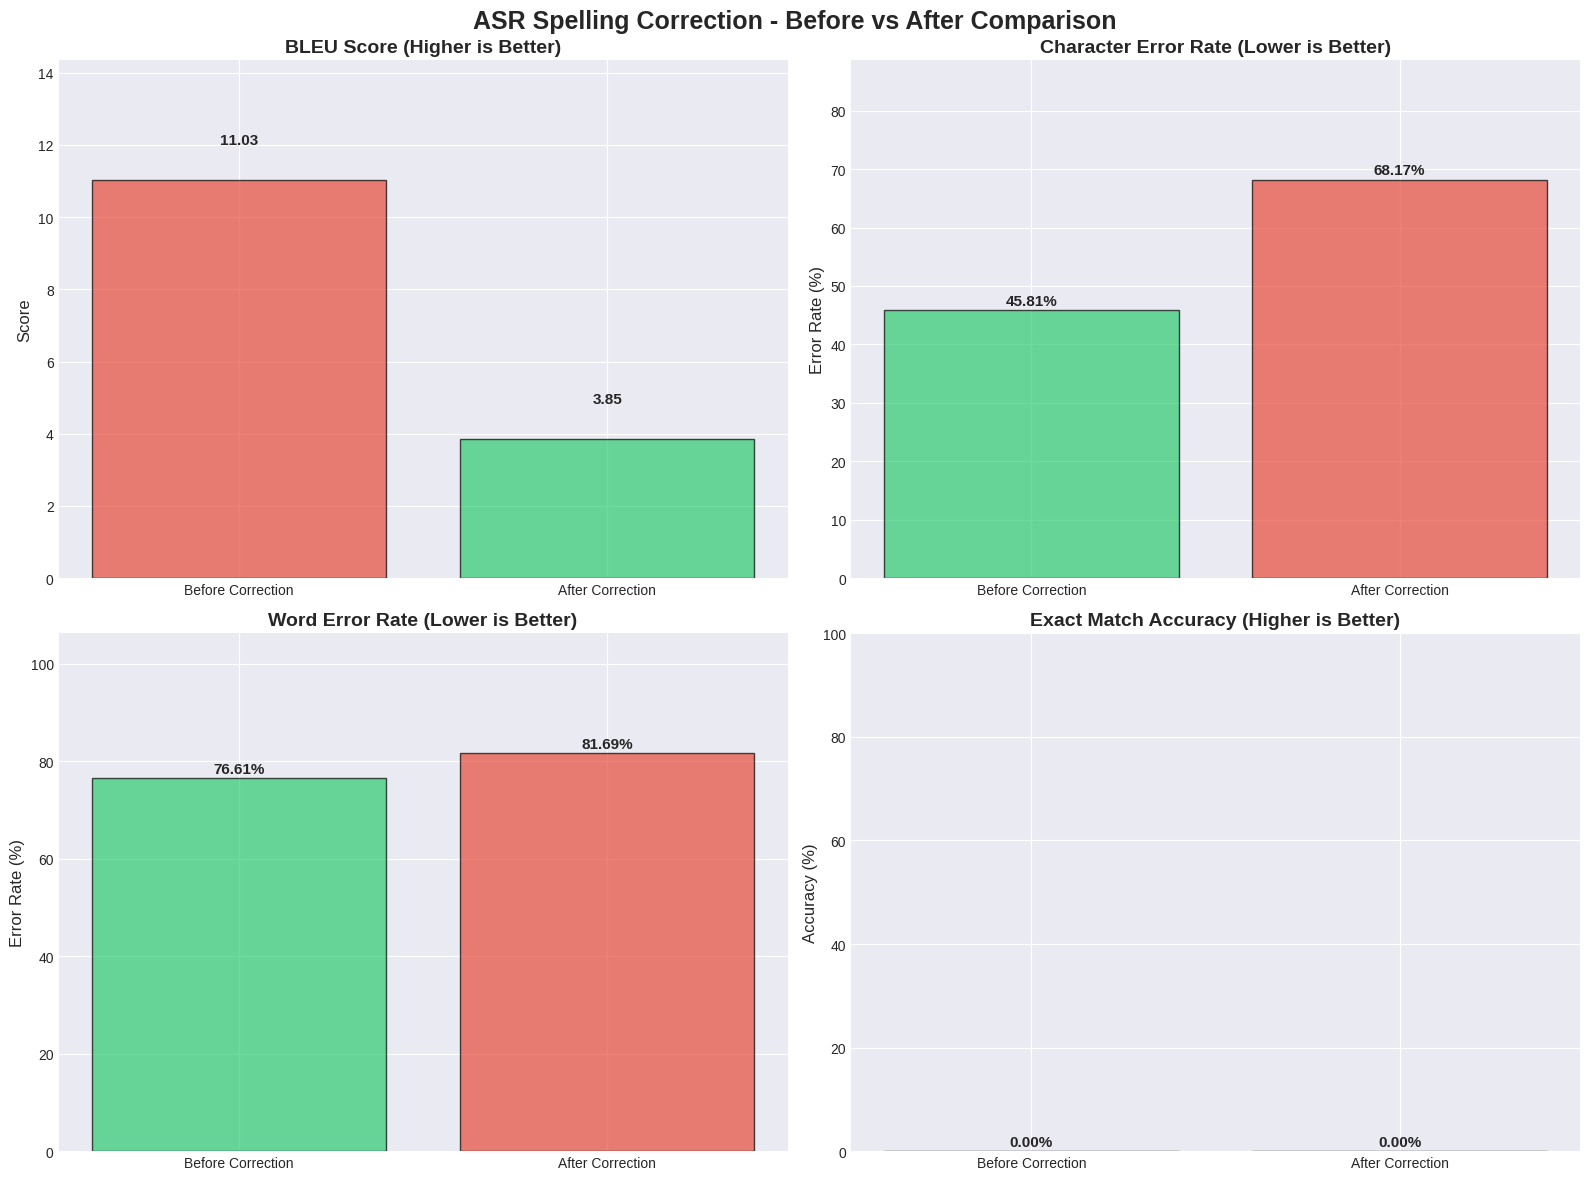


✓ Comparison visualization saved as 'asr_correction_comparison.png'


In [12]:
# Create comparison bar chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ASR Spelling Correction - Before vs After Comparison', fontsize=18, fontweight='bold')

# BLEU Score comparison
ax1 = axes[0, 0]
x = ['Before Correction', 'After Correction']
bleu_values = [metrics_before['bleu'], metrics_after['bleu']]
colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(x, bleu_values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('BLEU Score (Higher is Better)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(bleu_values) * 1.3)
for bar, value in zip(bars, bleu_values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{value:.2f}', ha='center', fontsize=11, fontweight='bold')

# CER comparison
ax2 = axes[0, 1]
cer_values = [metrics_before['cer'], metrics_after['cer']]
colors = ['#e74c3c', '#2ecc71'] if cer_values[1] < cer_values[0] else ['#2ecc71', '#e74c3c']
bars = ax2.bar(x, cer_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Error Rate (%)', fontsize=12)
ax2.set_title('Character Error Rate (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(cer_values) * 1.3)
for bar, value in zip(bars, cer_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{value:.2f}%', ha='center', fontsize=11, fontweight='bold')

# WER comparison
ax3 = axes[1, 0]
wer_values = [metrics_before['wer'], metrics_after['wer']]
colors = ['#e74c3c', '#2ecc71'] if wer_values[1] < wer_values[0] else ['#2ecc71', '#e74c3c']
bars = ax3.bar(x, wer_values, color=colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('Error Rate (%)', fontsize=12)
ax3.set_title('Word Error Rate (Lower is Better)', fontsize=14, fontweight='bold')
ax3.set_ylim(0, max(wer_values) * 1.3)
for bar, value in zip(bars, wer_values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{value:.2f}%', ha='center', fontsize=11, fontweight='bold')

# Exact Match comparison
ax4 = axes[1, 1]
em_values = [metrics_before['exact_match'], metrics_after['exact_match']]
colors = ['#e74c3c', '#2ecc71']
bars = ax4.bar(x, em_values, color=colors, alpha=0.7, edgecolor='black')
ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Exact Match Accuracy (Higher is Better)', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 100)
for bar, value in zip(bars, em_values):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{value:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('asr_correction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison visualization saved as 'asr_correction_comparison.png'")

## Step 11: Error Distribution Analysis

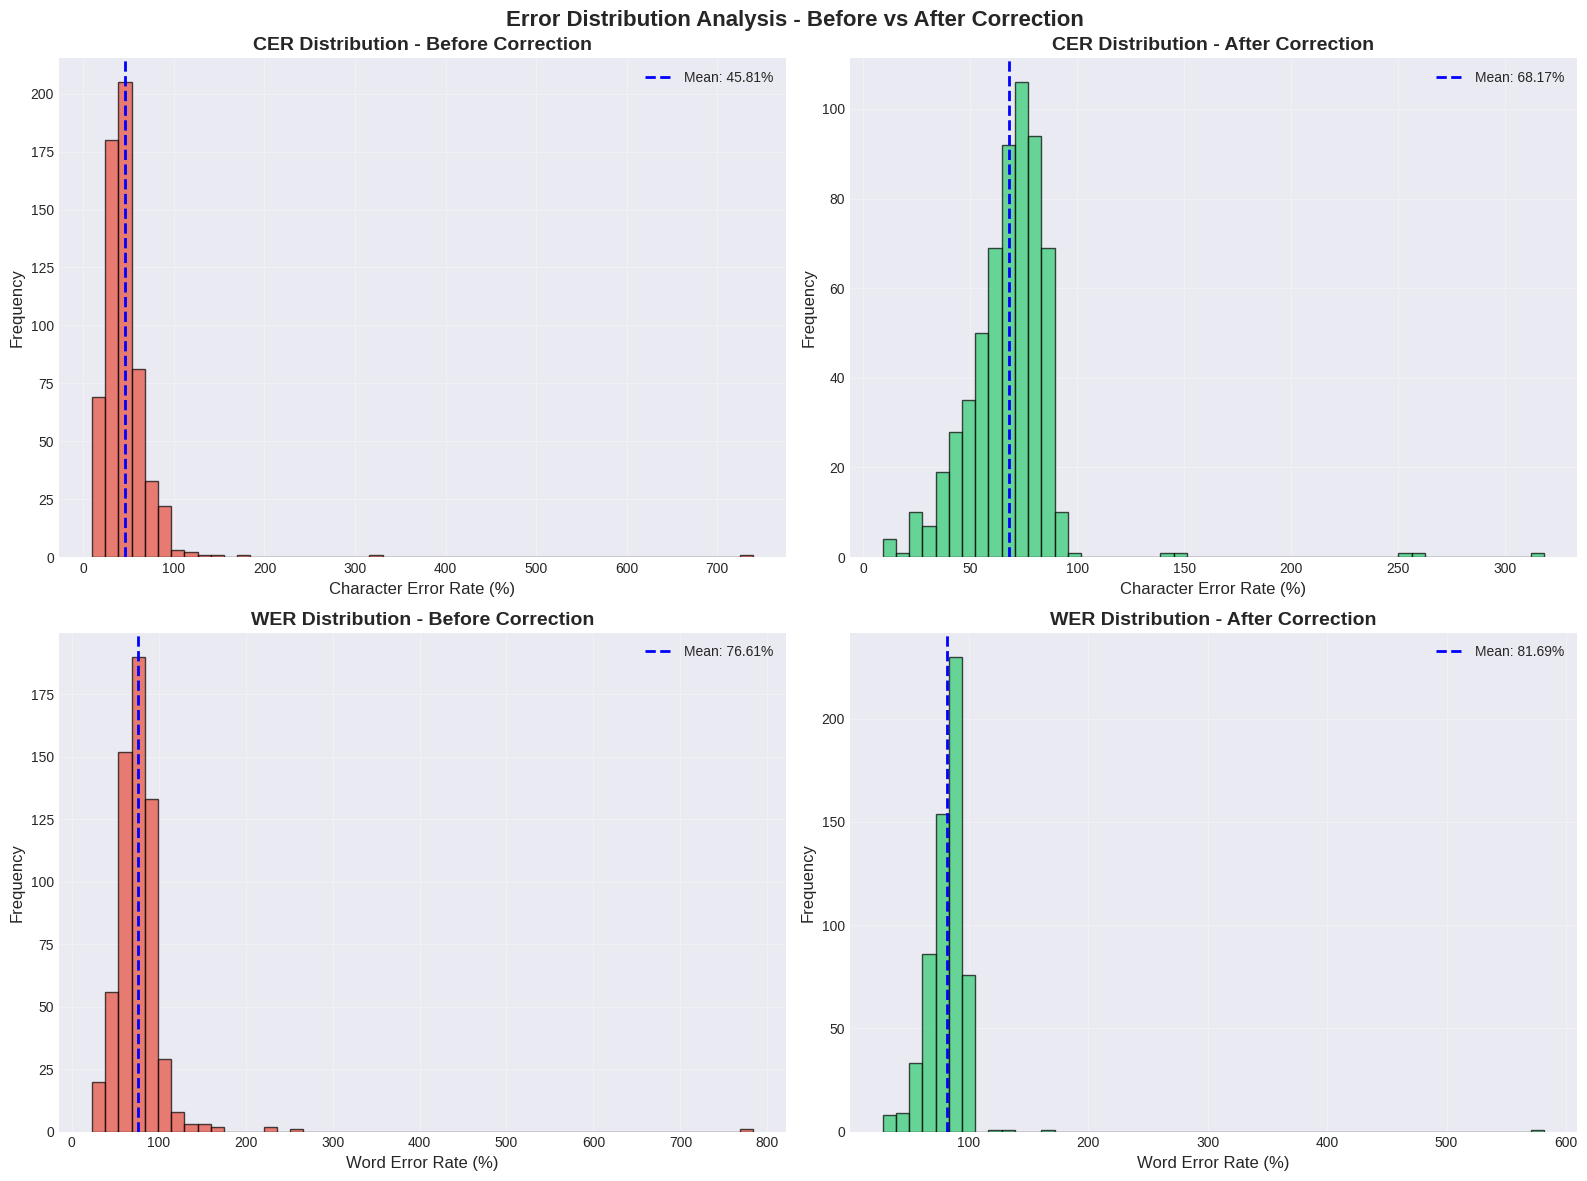


Error Statistics:

Before Correction:
  CER - Min: 9.30%, Max: 739.39%, Std: 36.28%
  WER - Min: 23.08%, Max: 783.33%, Std: 36.88%

After Correction:
  CER - Min: 9.09%, Max: 318.10%, Std: 22.11%
  WER - Min: 27.78%, Max: 581.40%, Std: 24.85%

✓ Error distribution comparison saved as 'error_distribution_comparison.png'


In [13]:
# Create error distribution plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Error Distribution Analysis - Before vs After Correction', fontsize=16, fontweight='bold')

# CER Distribution - Before
ax1 = axes[0, 0]
cer_before_pct = [c * 100 for c in cer_scores_before]
ax1.hist(cer_before_pct, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
ax1.axvline(metrics_before['cer'], color='blue', linestyle='--', linewidth=2, label=f'Mean: {metrics_before["cer"]:.2f}%')
ax1.set_xlabel('Character Error Rate (%)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('CER Distribution - Before Correction', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# CER Distribution - After
ax2 = axes[0, 1]
cer_after_pct = [c * 100 for c in cer_scores_after]
ax2.hist(cer_after_pct, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
ax2.axvline(metrics_after['cer'], color='blue', linestyle='--', linewidth=2, label=f'Mean: {metrics_after["cer"]:.2f}%')
ax2.set_xlabel('Character Error Rate (%)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('CER Distribution - After Correction', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# WER Distribution - Before
ax3 = axes[1, 0]
wer_before_pct = [w * 100 for w in wer_scores_before]
ax3.hist(wer_before_pct, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
ax3.axvline(metrics_before['wer'], color='blue', linestyle='--', linewidth=2, label=f'Mean: {metrics_before["wer"]:.2f}%')
ax3.set_xlabel('Word Error Rate (%)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('WER Distribution - Before Correction', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# WER Distribution - After
ax4 = axes[1, 1]
wer_after_pct = [w * 100 for w in wer_scores_after]
ax4.hist(wer_after_pct, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
ax4.axvline(metrics_after['wer'], color='blue', linestyle='--', linewidth=2, label=f'Mean: {metrics_after["wer"]:.2f}%')
ax4.set_xlabel('Word Error Rate (%)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('WER Distribution - After Correction', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nError Statistics:")
print(f"\nBefore Correction:")
print(f"  CER - Min: {min(cer_before_pct):.2f}%, Max: {max(cer_before_pct):.2f}%, Std: {np.std(cer_before_pct):.2f}%")
print(f"  WER - Min: {min(wer_before_pct):.2f}%, Max: {max(wer_before_pct):.2f}%, Std: {np.std(wer_before_pct):.2f}%")

print(f"\nAfter Correction:")
print(f"  CER - Min: {min(cer_after_pct):.2f}%, Max: {max(cer_after_pct):.2f}%, Std: {np.std(cer_after_pct):.2f}%")
print(f"  WER - Min: {min(wer_after_pct):.2f}%, Max: {max(wer_after_pct):.2f}%, Std: {np.std(wer_after_pct):.2f}%")

print("\n✓ Error distribution comparison saved as 'error_distribution_comparison.png'")

## Step 12: Per-Sample Improvement Analysis


PER-SAMPLE IMPROVEMENT ANALYSIS

Character Error Rate (CER):
  ✓ Improved:    52 samples (8.7%)
  ✗ Degraded:   520 samples (86.7%)
  → Unchanged:   28 samples (4.7%)

Word Error Rate (WER):
  ✓ Improved:   126 samples (21.0%)
  ✗ Degraded:   360 samples (60.0%)
  → Unchanged:  114 samples (19.0%)


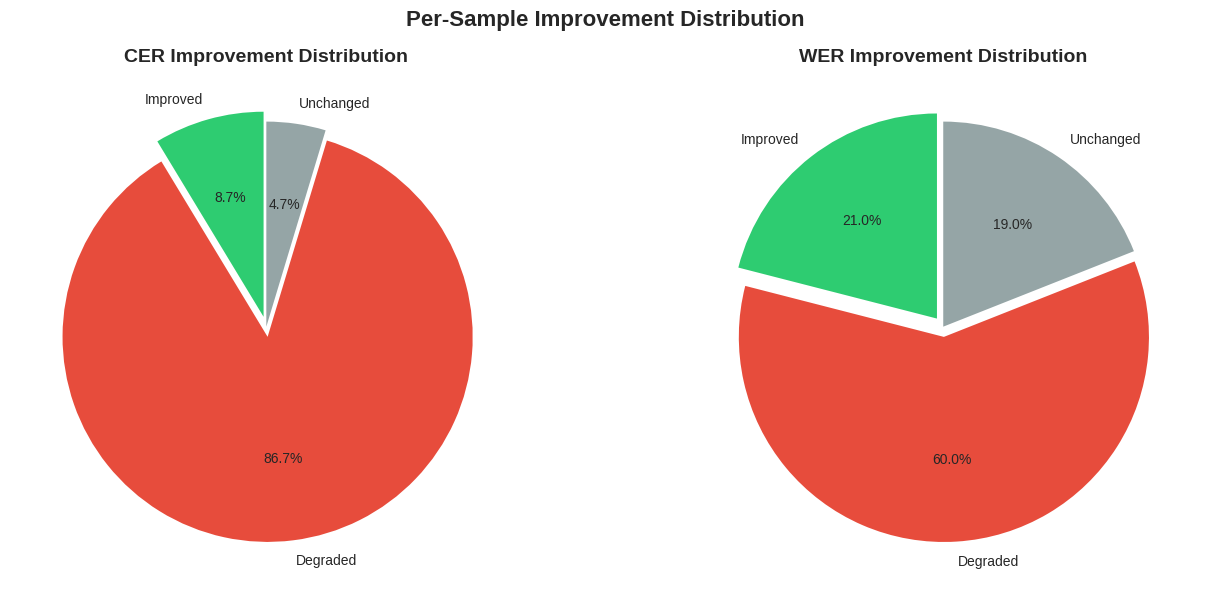


✓ Improvement distribution saved as 'improvement_distribution.png'


In [15]:
# Calculate per-sample improvement
cer_improvement = [before - after for before, after in zip(cer_scores_before, cer_scores_after)]
wer_improvement = [before - after for before, after in zip(wer_scores_before, wer_scores_after)]

# Count improvements vs degradations
cer_improved = sum(1 for x in cer_improvement if x > 0.01)  # Improved (positive = reduction in error)
cer_degraded = sum(1 for x in cer_improvement if x < -0.01)  # Degraded
cer_unchanged = len(cer_improvement) - cer_improved - cer_degraded

wer_improved = sum(1 for x in wer_improvement if x > 0.01)
wer_degraded = sum(1 for x in wer_improvement if x < -0.01)
wer_unchanged = len(wer_improvement) - wer_improved - wer_degraded

print(f"\n{'='*60}")
print("PER-SAMPLE IMPROVEMENT ANALYSIS")
print(f"{'='*60}\n")

print(f"Character Error Rate (CER):")
print(f"  ✓ Improved:  {cer_improved:4d} samples ({cer_improved/len(cer_improvement)*100:.1f}%)")
print(f"  ✗ Degraded:  {cer_degraded:4d} samples ({cer_degraded/len(cer_improvement)*100:.1f}%)")
print(f"  → Unchanged: {cer_unchanged:4d} samples ({cer_unchanged/len(cer_improvement)*100:.1f}%)")

print(f"\nWord Error Rate (WER):")
print(f"  ✓ Improved:  {wer_improved:4d} samples ({wer_improved/len(wer_improvement)*100:.1f}%)")
print(f"  ✗ Degraded:  {wer_degraded:4d} samples ({wer_degraded/len(wer_improvement)*100:.1f}%)")
print(f"  → Unchanged: {wer_unchanged:4d} samples ({wer_unchanged/len(wer_improvement)*100:.1f}%)")

# Create pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Per-Sample Improvement Distribution', fontsize=16, fontweight='bold')

# CER pie chart
ax1 = axes[0]
labels = ['Improved', 'Degraded', 'Unchanged']
sizes = [cer_improved, cer_degraded, cer_unchanged]
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
explode = (0.05, 0.05, 0)
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('CER Improvement Distribution', fontsize=14, fontweight='bold')

# WER pie chart
ax2 = axes[1]
sizes = [wer_improved, wer_degraded, wer_unchanged]
ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('WER Improvement Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('improvement_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Improvement distribution saved as 'improvement_distribution.png'")

## Step 13: Sample Predictions Table

In [16]:
# Create detailed results dataframe
results_df = pd.DataFrame({
    'Reference': references,
    'ASR_Prediction': asr_predictions,
    'Corrected': corrected_predictions,
    'CER_Before': [c * 100 for c in cer_scores_before],
    'CER_After': [c * 100 for c in cer_scores_after],
    'CER_Improvement': [i * 100 for i in cer_improvement],
    'WER_Before': [w * 100 for w in wer_scores_before],
    'WER_After': [w * 100 for w in wer_scores_after],
    'WER_Improvement': [i * 100 for i in wer_improvement]
})

# Sort by CER improvement to show best improvements first
results_df_sorted = results_df.sort_values('CER_Improvement', ascending=False)

print(f"\n{'='*80}")
print(f"TOP {CONFIG['sample_display_size']} MOST IMPROVED SAMPLES (by CER reduction)")
print(f"{'='*80}\n")

for idx, row in results_df_sorted.head(CONFIG['sample_display_size']).iterrows():
    print(f"Sample #{idx+1}")
    print(f"  Reference:     {row['Reference'][:100]}..." if len(str(row['Reference'])) > 100 else f"  Reference:     {row['Reference']}")
    print(f"  ASR Output:    {row['ASR_Prediction'][:100]}..." if len(str(row['ASR_Prediction'])) > 100 else f"  ASR Output:    {row['ASR_Prediction']}")
    print(f"  Corrected:     {row['Corrected'][:100]}..." if len(str(row['Corrected'])) > 100 else f"  Corrected:     {row['Corrected']}")
    print(f"  CER: {row['CER_Before']:.2f}% → {row['CER_After']:.2f}% (Δ {row['CER_Improvement']:.2f}%)")
    print(f"  WER: {row['WER_Before']:.2f}% → {row['WER_After']:.2f}% (Δ {row['WER_Improvement']:.2f}%)")
    print("-" * 80)


TOP 20 MOST IMPROVED SAMPLES (by CER reduction)

Sample #239
  Reference:     ඕන වෙලාවක අපිට message එකක් දාන්න
  ASR Output:    ඔනොවෙලා අපිට මැසේජ් එකක් දාන් සහ කෝල් එකක් තීලා ඔන්ලා කමෙන්ස්කෙන් සහාලුතෙනෙකතු වෙන්නවොන් දේවකෙන් අපි...
  Corrected:     ඔනොවෙලා අපිට මැසේජ් එකක් දාන් ඒවායින් කතා කරන්න හොද දේවල් තියෙනවා
  CER: 739.39% → 139.39% (Δ 600.00%)
  WER: 783.33% → 166.67% (Δ 616.67%)
--------------------------------------------------------------------------------
Sample #42
  Reference:     දෙන්න එපා. අට්ටි ගහලා කොහෙද ඕක දැන් තියාගන්නේ.
  ASR Output:    අමුට තියෙන්නේ බා. අට්ටි කාලකොවේත ඔවේත තියාගන්න තපි එරන්දි හොන්නට එයාන්නට එයාන්නට එයාන්නට එයාන්නවා එය...
  Corrected:     අමුට තියෙන්නේ බා. අට්ටි කාලකොවේත ඔවේත තියාගන්න එයාන්නට එයාන්නවා එයාන්නවා එයාන්නවා එයාන්නවා
  CER: 322.73% → 147.73% (Δ 175.00%)
  WER: 262.50% → 137.50% (Δ 125.00%)
--------------------------------------------------------------------------------
Sample #158
  Reference:     නංගිට ගනන් උගන්නන්න කියලා පටන් ගතතේ. ඔය 

## Step 14: Interactive Plotly Dashboard

In [17]:
# Create interactive plotly dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Metrics Comparison', 'Error Rate Reduction',
                    'CER Improvement Distribution', 'WER Improvement Distribution'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'histogram'}, {'type': 'histogram'}]]
)

# Metrics comparison bar chart
metrics_names = ['BLEU', 'CER', 'WER', 'Exact Match']
before_values = [metrics_before['bleu'], metrics_before['cer'], metrics_before['wer'], metrics_before['exact_match']]
after_values = [metrics_after['bleu'], metrics_after['cer'], metrics_after['wer'], metrics_after['exact_match']]

fig.add_trace(
    go.Bar(name='Before Correction', x=metrics_names, y=before_values, marker_color='#e74c3c'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(name='After Correction', x=metrics_names, y=after_values, marker_color='#2ecc71'),
    row=1, col=1
)

# Error rate reduction
improvements = ['CER Reduction', 'WER Reduction']
improvement_values = [metrics_before['cer'] - metrics_after['cer'], metrics_before['wer'] - metrics_after['wer']]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in improvement_values]

fig.add_trace(
    go.Bar(x=improvements, y=improvement_values, marker_color=colors, showlegend=False),
    row=1, col=2
)

# CER improvement histogram
fig.add_trace(
    go.Histogram(x=[i * 100 for i in cer_improvement], nbinsx=50, marker_color='#3498db', showlegend=False),
    row=2, col=1
)

# WER improvement histogram
fig.add_trace(
    go.Histogram(x=[i * 100 for i in wer_improvement], nbinsx=50, marker_color='#9b59b6', showlegend=False),
    row=2, col=2
)

fig.update_layout(
    title_text="ASR Spelling Correction Evaluation Dashboard",
    title_font_size=20,
    height=800,
    showlegend=True,
    barmode='group'
)

fig.update_xaxes(title_text="Improvement (%)", row=2, col=1)
fig.update_xaxes(title_text="Improvement (%)", row=2, col=2)
fig.update_yaxes(title_text="Frequency", row=2, col=1)
fig.update_yaxes(title_text="Frequency", row=2, col=2)

fig.show()

# Save as HTML
fig.write_html("asr_correction_dashboard.html")
print("\n✓ Interactive dashboard saved as 'asr_correction_dashboard.html'")


✓ Interactive dashboard saved as 'asr_correction_dashboard.html'


## Step 15: Save Results to CSV

In [18]:
# Save detailed results to CSV
output_csv_path = 'asr_spelling_correction_results.csv'
results_df.to_csv(output_csv_path, index=False)

# Save summary metrics
summary_df = pd.DataFrame({
    'Metric': ['BLEU', 'CER (%)', 'WER (%)', 'Exact Match (%)'],
    'Before_Correction': [metrics_before['bleu'], metrics_before['cer'], metrics_before['wer'], metrics_before['exact_match']],
    'After_Correction': [metrics_after['bleu'], metrics_after['cer'], metrics_after['wer'], metrics_after['exact_match']],
    'Improvement': [
        metrics_after['bleu'] - metrics_before['bleu'],
        metrics_before['cer'] - metrics_after['cer'],
        metrics_before['wer'] - metrics_after['wer'],
        metrics_after['exact_match'] - metrics_before['exact_match']
    ]
})

summary_csv_path = 'asr_spelling_correction_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)

print(f"\n{'='*60}")
print("RESULTS SAVED")
print(f"{'='*60}\n")
print(f"✓ Detailed results saved to: {output_csv_path}")
print(f"✓ Summary metrics saved to: {summary_csv_path}")
print(f"\nSummary:")
display(summary_df)


RESULTS SAVED

✓ Detailed results saved to: asr_spelling_correction_results.csv
✓ Summary metrics saved to: asr_spelling_correction_summary.csv

Summary:


,Metric,Before_Correction,After_Correction,Improvement
0,BLEU,11.034132,3.853566,-7.180566
1,CER (%),45.814115,68.166435,-22.352320
2,WER (%),76.608427,81.690812,-5.082384
3,Exact Match (%),0.000000,0.000000,0.000000


## Step 16: Final Summary

In [19]:
print(f"\n{'='*80}")
print("ASR SPELLING CORRECTION EVALUATION - FINAL SUMMARY")
print(f"{'='*80}\n")

print(f"Model: {CONFIG['model_path']}")
print(f"Dataset: {CONFIG['csv_path']}")
print(f"Total Samples: {len(references)}")
print(f"\n{'-'*80}")

print(f"\nRESULTS SUMMARY:")
print(f"\n  BLEU Score:")
print(f"    Before: {metrics_before['bleu']:.2f} → After: {metrics_after['bleu']:.2f}")
bleu_change = metrics_after['bleu'] - metrics_before['bleu']
print(f"    Change: {'+' if bleu_change >= 0 else ''}{bleu_change:.2f} points")

print(f"\n  Character Error Rate (CER):")
print(f"    Before: {metrics_before['cer']:.2f}% → After: {metrics_after['cer']:.2f}%")
cer_change = metrics_before['cer'] - metrics_after['cer']
print(f"    Reduction: {cer_change:.2f}% ({cer_change/metrics_before['cer']*100:.1f}% relative improvement)" if cer_change > 0 else f"    Increase: {abs(cer_change):.2f}%")

print(f"\n  Word Error Rate (WER):")
print(f"    Before: {metrics_before['wer']:.2f}% → After: {metrics_after['wer']:.2f}%")
wer_change = metrics_before['wer'] - metrics_after['wer']
print(f"    Reduction: {wer_change:.2f}% ({wer_change/metrics_before['wer']*100:.1f}% relative improvement)" if wer_change > 0 else f"    Increase: {abs(wer_change):.2f}%")

print(f"\n  Exact Match Accuracy:")
print(f"    Before: {metrics_before['exact_match']:.2f}% → After: {metrics_after['exact_match']:.2f}%")
em_change = metrics_after['exact_match'] - metrics_before['exact_match']
print(f"    Change: {'+' if em_change >= 0 else ''}{em_change:.2f}%")

print(f"\n{'-'*80}")
print(f"\nSAMPLE-LEVEL ANALYSIS:")
print(f"  CER Improved: {cer_improved}/{len(cer_improvement)} samples ({cer_improved/len(cer_improvement)*100:.1f}%)")
print(f"  WER Improved: {wer_improved}/{len(wer_improvement)} samples ({wer_improved/len(wer_improvement)*100:.1f}%)")

print(f"\n{'='*80}")
print("EVALUATION COMPLETE")
print(f"{'='*80}")


ASR SPELLING CORRECTION EVALUATION - FINAL SUMMARY

Model: SPEAK-ASR/mBART-large-50-si-spelling-v2
Dataset: /content/drive/MyDrive/FYP/Evaluation - whisper-small-si-openslr_plus_youtube_data - SPEAK-ASR_biz-brains-academy-sinhala.csv
Total Samples: 600

--------------------------------------------------------------------------------

RESULTS SUMMARY:

  BLEU Score:
    Before: 11.03 → After: 3.85
    Change: -7.18 points

  Character Error Rate (CER):
    Before: 45.81% → After: 68.17%
    Increase: 22.35%

  Word Error Rate (WER):
    Before: 76.61% → After: 81.69%
    Increase: 5.08%

  Exact Match Accuracy:
    Before: 0.00% → After: 0.00%
    Change: +0.00%

--------------------------------------------------------------------------------

SAMPLE-LEVEL ANALYSIS:
  CER Improved: 52/600 samples (8.7%)
  WER Improved: 126/600 samples (21.0%)

EVALUATION COMPLETE
